In [3]:
import pandas as pd

In [6]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


#### Primeiramente, carregar os dados e certificar-se que não há valores nulos

In [7]:
df = pd.read_csv('/content/credit_card_fraud_prediction/dataset/creditcard_2023.csv')

In [8]:
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,22063.00000,22063.000000,22063.000000,22063.000000,22063.000000,22063.000000,22063.000000,22063.000000,22063.000000,22063.000000,...,22062.000000,22062.000000,22062.000000,22062.000000,22062.000000,22062.000000,22062.000000,22062.000000,22062.000000,22062.000000
mean,11031.00000,0.318721,-0.408192,1.090485,-0.614805,0.262792,0.484053,0.436514,-0.137625,0.975891,...,-0.127388,-0.148562,-0.052228,0.145798,0.137595,-0.017522,-0.200200,-0.085687,11936.589789,0.003898
std,6369.18383,0.626984,0.582128,0.733391,0.663944,0.675072,0.727932,0.475007,0.299854,0.941279,...,0.319918,0.578170,0.506088,1.097061,0.711201,1.154768,0.446512,0.597075,6929.582935,0.062314
min,0.00000,-2.637662,-25.480046,-2.518308,-4.468314,-4.298320,-18.642598,-3.038728,-6.595785,-2.170915,...,-10.699713,-6.262872,-19.297443,-4.067968,-10.230967,-3.733169,-5.536809,-9.015933,50.410000,0.000000
25%,5515.50000,-0.150595,-0.569125,0.627737,-0.966883,-0.007267,0.082270,0.248347,-0.190253,0.333886,...,-0.207642,-0.542428,-0.199053,-0.563107,-0.303142,-0.812983,-0.313297,-0.124276,5933.507500,0.000000
50%,11031.00000,0.074560,-0.375684,1.003228,-0.525938,0.174404,0.373407,0.409521,-0.146501,0.824874,...,-0.147483,-0.145129,-0.072790,0.155936,0.183934,-0.083106,-0.231227,-0.052364,11819.845000,0.000000
75%,16546.50000,0.962797,-0.171197,1.501920,-0.169403,0.390729,0.742463,0.599338,-0.087553,1.445220,...,-0.079069,0.208014,0.051672,0.846075,0.587689,0.705751,-0.126251,0.087408,17955.035000,0.000000
max,22062.00000,1.695400,3.368287,4.440555,2.360359,41.540257,9.295606,37.922674,5.958040,12.171681,...,6.834415,6.492043,18.418155,9.978778,10.424231,5.623285,17.987212,11.375357,24039.880000,1.000000


### Features do nosso dataset possui seguintes descrições:
- id: Identificador único de cada transação
- V1-V28: Features anonimizadas representando vários atributos de transação (e.g., hora, local, etc.)
- Amount: Quantia da transação
- Class: Label binário indicando se a transação é fraudulenta (1) ou não (0)

---



In [9]:
df = df.dropna()

### Na sequência, precisamos remover a coluna de ID já que não queremos que o modelo tente encontrar padrões com relação a coluna

In [10]:
df_new = df.drop(columns=['id'])

In [11]:
df_new.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0.0
1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0.0
2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0.0
3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0.0
4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0.0


### Agora precisamos separar as features do target
---

In [12]:
x = df_new.drop(columns=['Class'])
y = df_new['Class']

### Vamos fazer a primeira divisão de dados entre valores the teste para o dataset em 15% para teste final

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

### Nesse caso, vamos separar o restante dos 85% dos valores em 15% para validação, sendo assim necessário realizar o cálculo de 15% de 85%

In [15]:
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.176,
                                                  random_state=42)

In [16]:
print(y_val)

1548     0.0
16330    0.0
15531    0.0
11094    0.0
16528    0.0
        ... 
12118    0.0
17015    0.0
12912    0.0
15349    0.0
18521    0.0
Name: Class, Length: 3301, dtype: float64


### Por fim, antes de treinar nosso modelo, vamos redimensionar a coluna 'Amount' para nosso modelo

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [18]:
x_train['Amount'] = scaler.fit_transform(x_train[['Amount']])
x_val['Amount'] = scaler.transform(x_val[['Amount']])
x_test['Amount'] = scaler.transform(x_test[['Amount']])

In [19]:
print(x_train)

             V1        V2        V3        V4        V5        V6        V7  \
16418 -0.363045 -0.282609  1.969270 -0.438432  0.202996  0.929067  0.426644   
4532   0.086020 -0.139130  2.128600 -0.289351  0.306081  0.176340  0.677800   
667   -0.171013 -0.241833  2.590608 -0.072442  0.144209  1.079975  0.536568   
6332   1.106487 -0.790747  0.506097 -2.341949 -0.120864 -0.030817  0.211653   
8318   0.985333 -0.200367  0.932971  0.327990  0.246599  0.191590  0.473917   
...         ...       ...       ...       ...       ...       ...       ...   
9669   0.986388 -0.503234  0.809278 -0.542278  0.084532  0.424639  0.268782   
10563  0.932990 -0.316553  0.963347 -0.106352  0.179417  0.401869  0.371262   
7453   0.844437 -0.751101  0.732181 -0.339218 -0.007237  0.728777  0.216811   
6253   1.024826 -0.829044  1.609904 -0.729197 -0.215268  1.098208 -0.053852   
4020   0.947811 -0.349540  0.745714 -0.293761  0.164025  0.260676  0.355381   

             V8        V9       V10  ...       V20 

## Seguir agora com a validação do modelo de Regressão Logística

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [22]:
y_val_pred = log_reg.predict(x_val)
y_val_proba = log_reg.predict_proba(x_val)[:, 1]

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("PR-AUC:", average_precision_score(y_val, y_val_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Accuracy: 0.9990911844895486
Precision: 1.0
Recall: 0.8235294117647058
F1-score: 0.9032258064516129
ROC-AUC: 0.9508490363258579
PR-AUC: 0.8298512924297982

Confusion Matrix:
[[3284    0]
 [   3   14]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3284
         1.0       1.00      0.82      0.90        17

    accuracy                           1.00      3301
   macro avg       1.00      0.91      0.95      3301
weighted avg       1.00      1.00      1.00      3301



### Criar tabela de comparação para futura análise de resultados com modelo não supervisionado

In [29]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_val, y_val_pred)
    ],
    "Precision": [
        precision_score(y_val, y_val_pred)
    ],
    "Recall": [
        recall_score(y_val, y_val_pred)
    ],
    "F1-score": [
        f1_score(y_val, y_val_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_val_proba)
    ],
    "PR-AUC": [
        average_precision_score(y_val, y_val_proba)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.999091,1.0,0.823529,0.903226,0.950849,0.829851


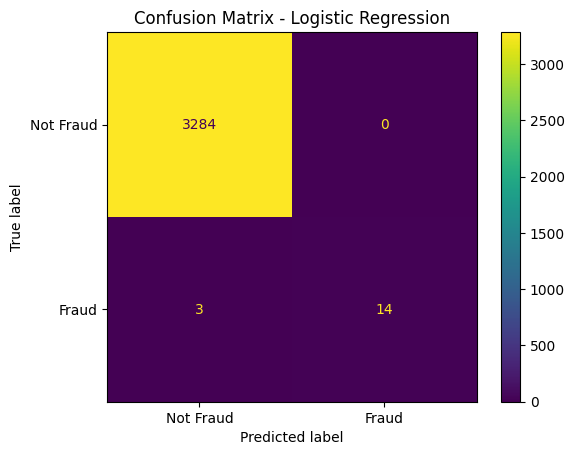

<Figure size 640x480 with 0 Axes>

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Fraud", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
plt.savefig("results/confusion_matrix_logistic_regression.png", dpi=300, bbox_inches="tight")

### Organização do Repositório e Envio para o GitHub

Nesta etapa, vamos garantir que o notebook e os resultados estejam na estrutura de pastas correta (`notebooks/` e `results/`) e sincronizar com o repositório remoto.

In [ ]:
import os
import nbformat
import json

# 1. Garantir que as pastas existam
os.makedirs('results', exist_ok=True)
os.makedirs('notebooks', exist_ok=True)

# 2. Salvar os resultados da regressão logística
results.to_csv('results/logistic_regression_results.csv', index=False)

# 3. Exportar o estado atual do notebook para a pasta notebooks/
from google.colab import _message
notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=5)

# O objeto retornado já é um dicionário, então usamos nbformat.from_dict
if isinstance(notebook_json['ipynb'], dict):
    nb_obj = nbformat.from_dict(notebook_json['ipynb'])
else:
    nb_obj = nbformat.reads(notebook_json['ipynb'], as_version=4)

with open('notebooks/projeto_tcc_credit_card_fraud_1.ipynb', 'w', encoding='utf-8') as f:
    nbformat.write(nb_obj, f)

print("Notebook e resultados organizados localmente.")

In [52]:
# 4. Limpeza de pastas duplicadas e Sincronização Git
!git config --global user.email "giannikleiss4@gmail.com"
!git config --global user.name "ggentile"

# Remove a pasta aninhada se ela existir acidentalmente no index ou disco
!rm -rf /content/credit_card_fraud_prediction
!git rm -r --cached credit_card_fraud_prediction --ignore-unmatch

# Adiciona os arquivos na estrutura correta
!git add notebooks/ results/

# Commit e Push
!git commit -m "Clean repository structure and update notebook"
!git push origin main

[main c9c3e30] Finalize notebook and results structure
 1 file changed, 1144 deletions(-)
 rewrite notebooks/projeto_tcc_credit_card_fraud_1.ipynb (100%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 351 bytes | 351.00 KiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/ggentile/credit_card_fraud_prediction.git
   a0d03ae..c9c3e30  main -> main
